# EDA — Heat Pump Grid Load
Monthly aggregated data: 600 devices × 13 months.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.3, "grid.linewidth": 0.5})

TEAL   = "#1D9E75"
CORAL  = "#D85A30"
BLUE   = "#378ADD"
AMBER  = "#BA7517"
GRAY   = "#888780"

DATA_FOLDER = '/net/tscratch/people/tutorial237/EnsembleAi2026/task3/data'
df = pd.read_parquet(f"{DATA_FOLDER}/monthly_agg.parquet")

TEMP_MEAN_COLS = [f"t{i}_mean" for i in range(1, 14)]
TEMP_STD_COLS  = [f"t{i}_std"  for i in range(1, 14)]

# Split into train (x2 known) and forecast (x2 withheld)
train_df = df[df["x2_mean"].notna()].copy()
fore_df  = df[df["x2_mean"].isna()].copy()

print(f"Total rows   : {len(df)}")
print(f"Train rows   : {len(train_df)}  (x2 known)")
print(f"Forecast rows: {len(fore_df)}  (x2 withheld)")

Total rows   : 7701
Train rows   : 4142  (x2 known)
Forecast rows: 3559  (x2 withheld)


## 1. Missing values

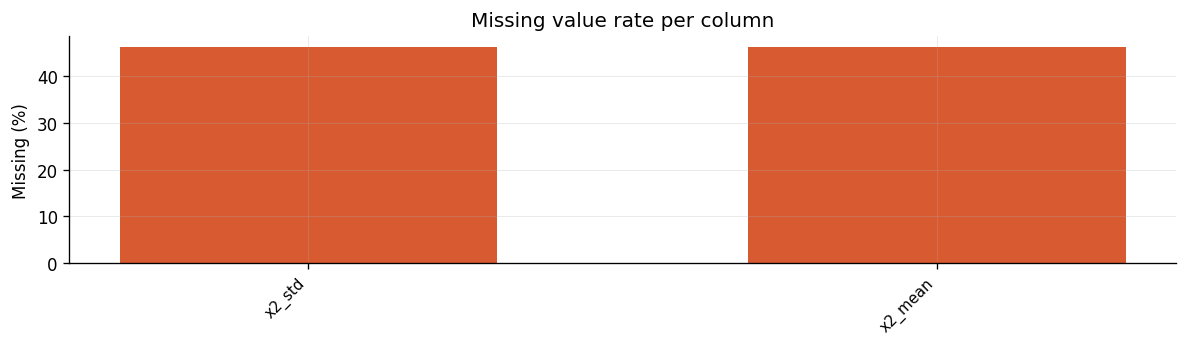

x2_std     46.2
x2_mean    46.2


In [2]:
miss = df.isnull().mean().mul(100).round(1).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, 3))
colors = [CORAL if v > 10 else AMBER if v > 1 else TEAL for v in miss.values]
ax.bar(miss.index, miss.values, color=colors, width=0.6)
ax.set_ylabel("Missing (%)")
ax.set_title("Missing value rate per column")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()
print(miss.to_string())

## 2. x2_mean — target distribution
`x2_mean` is the prediction target. Only available in train months (Oct 2024 – Apr 2025).

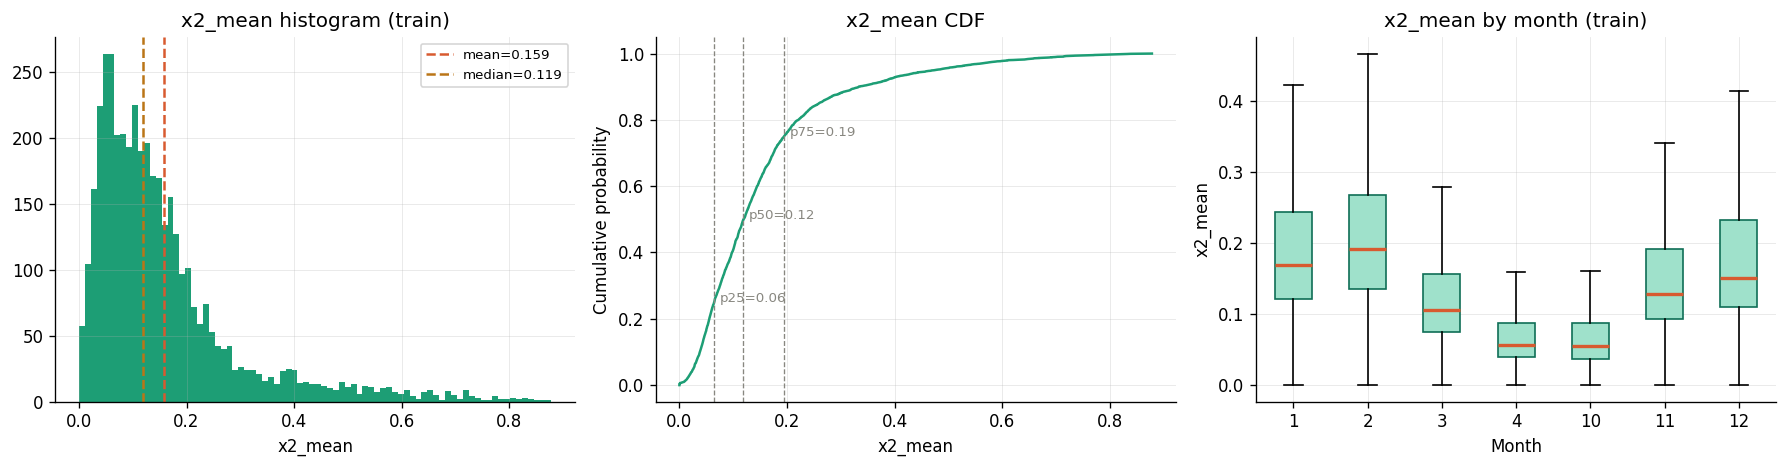

count    4142.0000
mean        0.1586
std         0.1408
min         0.0000
25%         0.0647
50%         0.1191
75%         0.1942
max         0.8783

Zeros : 0.4%
>0.5  : 4.4%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(train_df["x2_mean"], bins=80, color=TEAL, edgecolor="none")
axes[0].set_title("x2_mean histogram (train)")
axes[0].set_xlabel("x2_mean")
axes[0].axvline(train_df["x2_mean"].mean(), color=CORAL, linewidth=1.5,
                linestyle="--", label=f'mean={train_df["x2_mean"].mean():.3f}')
axes[0].axvline(train_df["x2_mean"].median(), color=AMBER, linewidth=1.5,
                linestyle="--", label=f'median={train_df["x2_mean"].median():.3f}')
axes[0].legend(fontsize=8)

# CDF
x_sorted = np.sort(train_df["x2_mean"].dropna())
axes[1].plot(x_sorted, np.linspace(0, 1, len(x_sorted)), color=TEAL, linewidth=1.5)
axes[1].set_title("x2_mean CDF")
axes[1].set_xlabel("x2_mean")
axes[1].set_ylabel("Cumulative probability")
for p, v in [(0.25, np.percentile(x_sorted, 25)),
             (0.50, np.percentile(x_sorted, 50)),
             (0.75, np.percentile(x_sorted, 75))]:
    axes[1].axvline(v, color=GRAY, linewidth=0.8, linestyle="--")
    axes[1].text(v+0.01, p, f"p{int(p*100)}={v:.2f}", fontsize=8, color=GRAY)

# Monthly boxplot (train only)
month_labels = sorted(train_df["month"].unique())
data_by_month = [train_df[train_df["month"]==m]["x2_mean"].dropna().values
                 for m in month_labels]
bp = axes[2].boxplot(data_by_month, labels=month_labels, showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="#9FE1CB", color="#0F6E56"),
                medianprops=dict(color=CORAL, linewidth=2))
axes[2].set_title("x2_mean by month (train)")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("x2_mean")

plt.tight_layout()
plt.show()

print(train_df["x2_mean"].describe().round(4).to_string())
print(f"\nZeros : {(train_df['x2_mean']==0).mean()*100:.1f}%")
print(f">0.5  : {(train_df['x2_mean']>0.5).mean()*100:.1f}%")

## 3. Seasonal pattern — monthly mean x2 across all devices

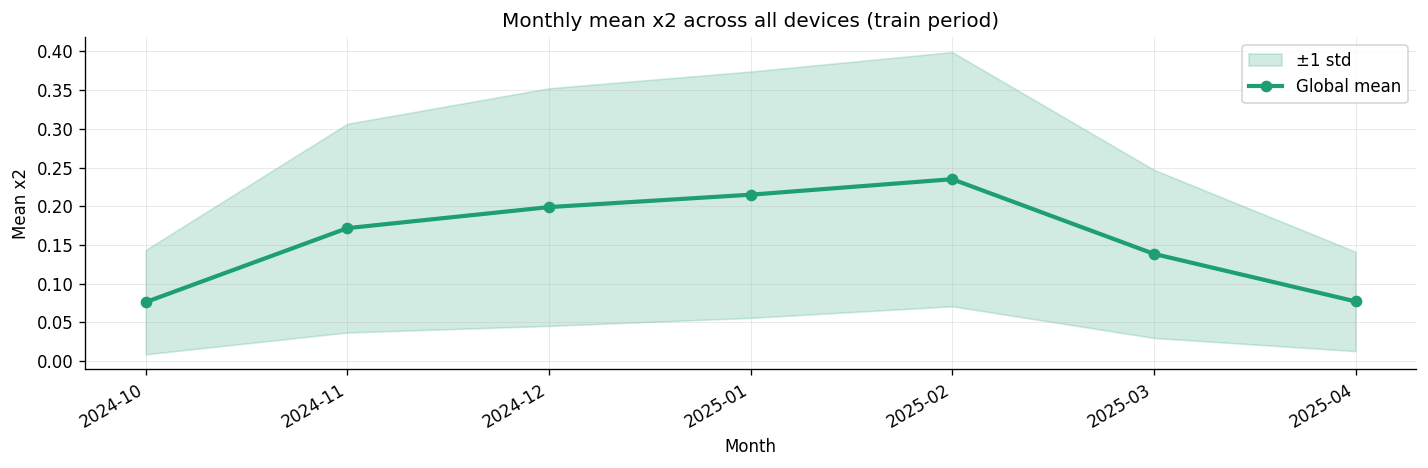

  label     mean      std  min      max
2024-10 0.076105 0.067401  0.0 0.479238
2024-11 0.171669 0.134819  0.0 0.770486
2024-12 0.198859 0.153505  0.0 0.854639
2025-01 0.214885 0.159126  0.0 0.878281
2025-02 0.234913 0.164192  0.0 0.865385
2025-03 0.138451 0.108620  0.0 0.619425
2025-04 0.077022 0.064204  0.0 0.408976


In [4]:
monthly_global = (train_df.groupby(["year","month"])["x2_mean"]
                  .agg(["mean","std","min","max"])
                  .reset_index()
                  .sort_values(["year","month"]))
monthly_global["label"] = (monthly_global["year"].astype(str) + "-"
                           + monthly_global["month"].astype(str).str.zfill(2))

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly_global["label"],
                monthly_global["mean"] - monthly_global["std"],
                monthly_global["mean"] + monthly_global["std"],
                alpha=0.2, color=TEAL, label="±1 std")
ax.plot(monthly_global["label"], monthly_global["mean"],
        color=TEAL, linewidth=2.5, marker="o", label="Global mean")
ax.set_title("Monthly mean x2 across all devices (train period)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean x2")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(monthly_global[["label","mean","std","min","max"]].to_string(index=False))

## 4. Per-device patterns
How much does x2 vary across devices, and how consistent are individual devices over time?

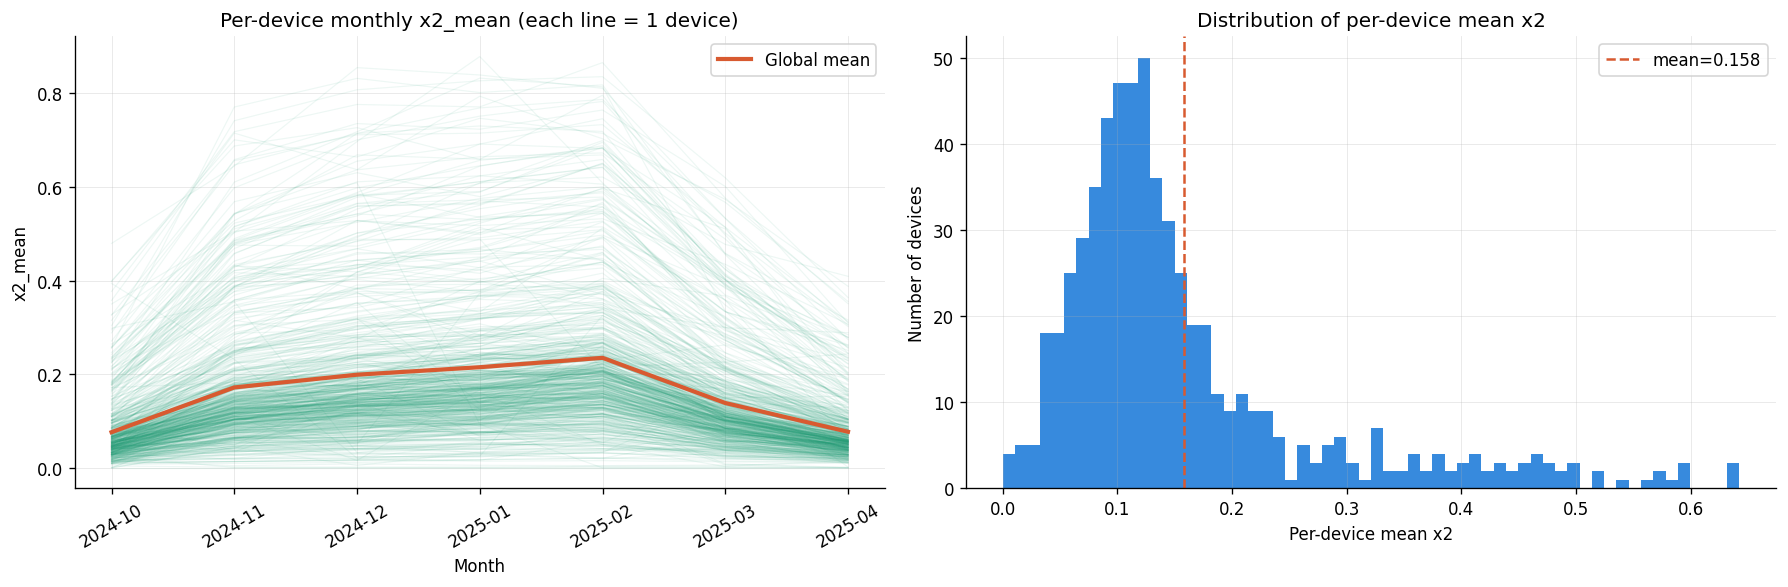

Per-device x2_mean summary:
count    600.0000
mean       0.1583
std        0.1175
min        0.0000
25%        0.0886
50%        0.1210
75%        0.1805
max        0.6425

Top 5 highest load devices:
deviceId
ba30b5fef6b7085e419c416d74e999df3ee83d563501424bdc0b5b1fe79ba11f    0.642452
e34670113bc0594b960557f79bf9dee8805f3657589dfe3a1b07e08dc3d833de    0.637927
70dcbe6d52d4efb68e6bc3477634c7a0712ce37a92f287791e5540fcde97700d    0.633353
198f7bb9ff2ca4470858cce4f8ba47cbf727c9d4d9220ffd1e692d0d346ada2b    0.595197
c9b377c6bffc53edca8e3628c037b949e9aec7b4576c7de0da99bb8775017a6b    0.592182

Top 5 lowest load devices:
deviceId
a4a44e2949a7db0f951ac94a601a1db2f5d993bcebb465efff7b810475161e17    0.000000
e5d0949a59a0e5a2f854d1da2e668bd9926cb00e55c9abf8660bdcf75bec29d5    0.004166
2783c80382125f5fa4b8f085257d7c59ec7e5971a893809d6834627d183e7564    0.004322
84088011a5445196a0d121760f03c4b58b7f357eb2342604f34b471efde637a6    0.007847
68f47e7f7e22a510cce68978eaa4c4234dd9a420465b7beeb1587ef04a77

In [5]:
dev_monthly = (train_df.groupby(["deviceId","year","month"])["x2_mean"]
               .mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# All device traces
month_order = (dev_monthly.assign(
    label=dev_monthly["year"].astype(str)+"-"+dev_monthly["month"].astype(str).str.zfill(2))
    .groupby("label")["year"].first().sort_values().index.tolist())

for did, grp in dev_monthly.groupby("deviceId"):
    grp = grp.sort_values(["year","month"])
    grp["label"] = grp["year"].astype(str)+"-"+grp["month"].astype(str).str.zfill(2)
    axes[0].plot(grp["label"], grp["x2_mean"],
                 alpha=0.08, linewidth=0.7, color=TEAL)

global_mean = dev_monthly.groupby(["year","month"])["x2_mean"].mean().reset_index()
global_mean["label"] = (global_mean["year"].astype(str)+"-"
                        +global_mean["month"].astype(str).str.zfill(2))
global_mean = global_mean.sort_values(["year","month"])
axes[0].plot(global_mean["label"], global_mean["x2_mean"],
             color=CORAL, linewidth=2.5, label="Global mean", zorder=5)
axes[0].set_title("Per-device monthly x2_mean (each line = 1 device)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("x2_mean")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Distribution of per-device mean x2 (collapsed across time)
dev_summary = train_df.groupby("deviceId")["x2_mean"].mean()
axes[1].hist(dev_summary, bins=60, color=BLUE, edgecolor="none")
axes[1].axvline(dev_summary.mean(), color=CORAL, linewidth=1.5, linestyle="--",
                label=f"mean={dev_summary.mean():.3f}")
axes[1].set_title("Distribution of per-device mean x2")
axes[1].set_xlabel("Per-device mean x2")
axes[1].set_ylabel("Number of devices")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Per-device x2_mean summary:")
print(dev_summary.describe().round(4).to_string())
print(f"\nTop 5 highest load devices:")
print(dev_summary.nlargest(5).to_string())
print(f"\nTop 5 lowest load devices:")
print(dev_summary.nsmallest(5).to_string())

## 5. Temperature feature correlations with x2_mean

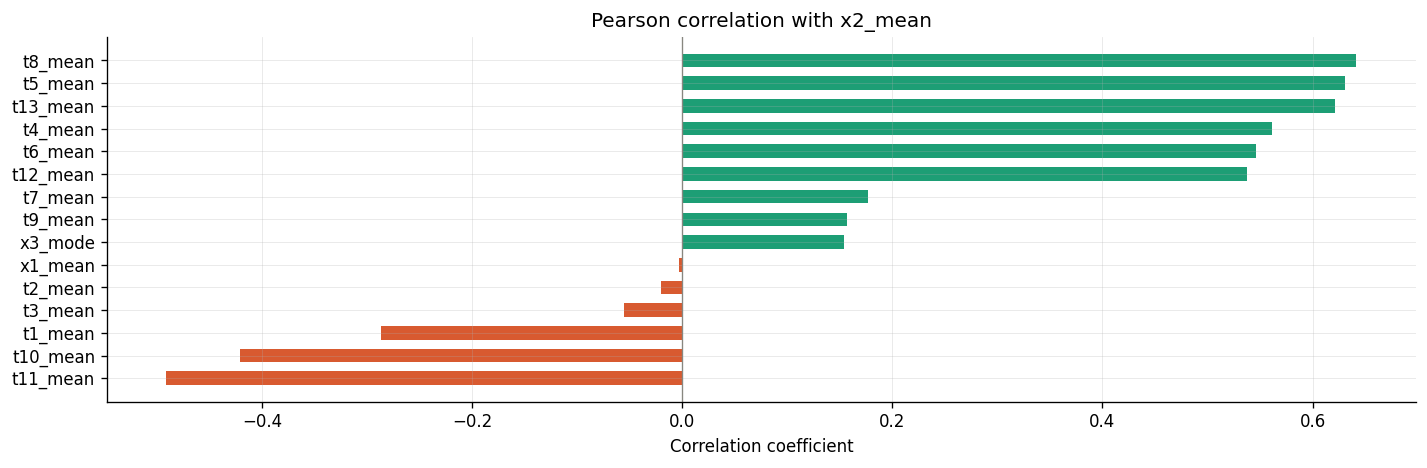

t11_mean   -0.491
t10_mean   -0.421
t1_mean    -0.287
t3_mean    -0.055
t2_mean    -0.020
x1_mean    -0.003
x3_mode     0.154
t9_mean     0.157
t7_mean     0.177
t12_mean    0.537
t6_mean     0.546
t4_mean     0.561
t13_mean    0.621
t5_mean     0.631
t8_mean     0.642


In [6]:
corr = (train_df[TEMP_MEAN_COLS + ["x1_mean","x3_mode","x2_mean"]]
        .corr()["x2_mean"]
        .drop("x2_mean")
        .sort_values())

fig, ax = plt.subplots(figsize=(12, 4))
colors = [CORAL if v < 0 else TEAL for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, height=0.6)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_title("Pearson correlation with x2_mean")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

## 6. Suspicious sensors — check t3 and x1 for zero-heavy columns

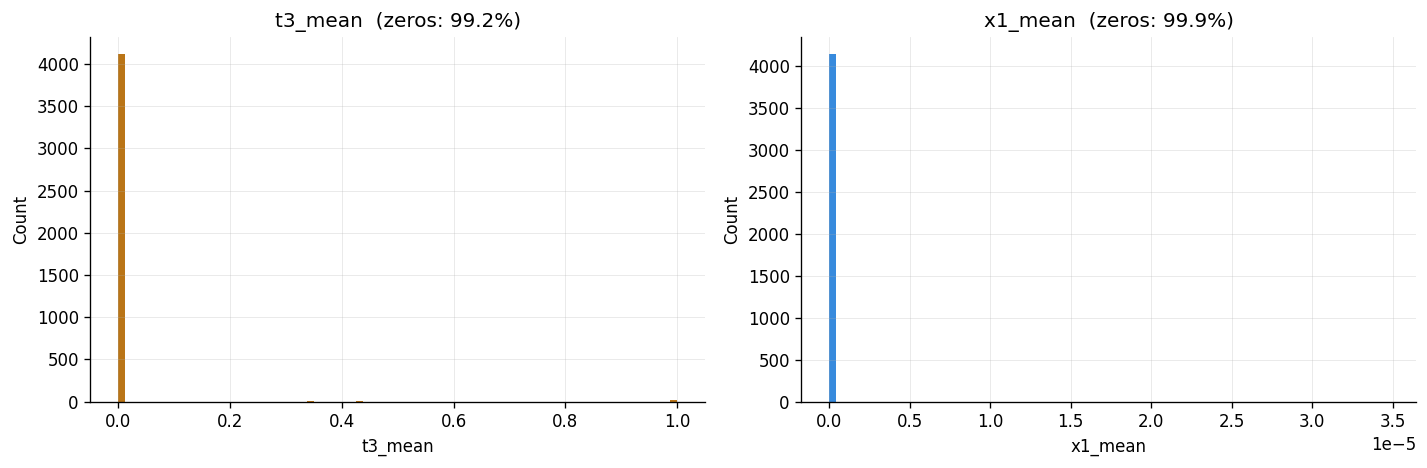

Zero rate (%) per feature:
x1_mean     99.9
t3_mean     99.2
t4_mean      0.2
t2_mean      0.0
t5_mean      0.0
t1_mean      0.0
t6_mean      0.0
t7_mean      0.0
t9_mean      0.0
t8_mean      0.0
t10_mean     0.0
t11_mean     0.0
t12_mean     0.0
t13_mean     0.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in [(axes[0], "t3_mean", AMBER), (axes[1], "x1_mean", BLUE)]:
    zero_pct = (train_df[col] == 0).mean() * 100
    ax.hist(train_df[col], bins=80, color=color, edgecolor="none")
    ax.set_title(f"{col}  (zeros: {zero_pct:.1f}%)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Per-column zero rate for all features
zero_rates = (train_df[TEMP_MEAN_COLS + ["x1_mean"]]==0).mean().mul(100).round(1)
zero_rates = zero_rates.sort_values(ascending=False)
print("Zero rate (%) per feature:")
print(zero_rates.to_string())

## 7. Device type & x2_mean

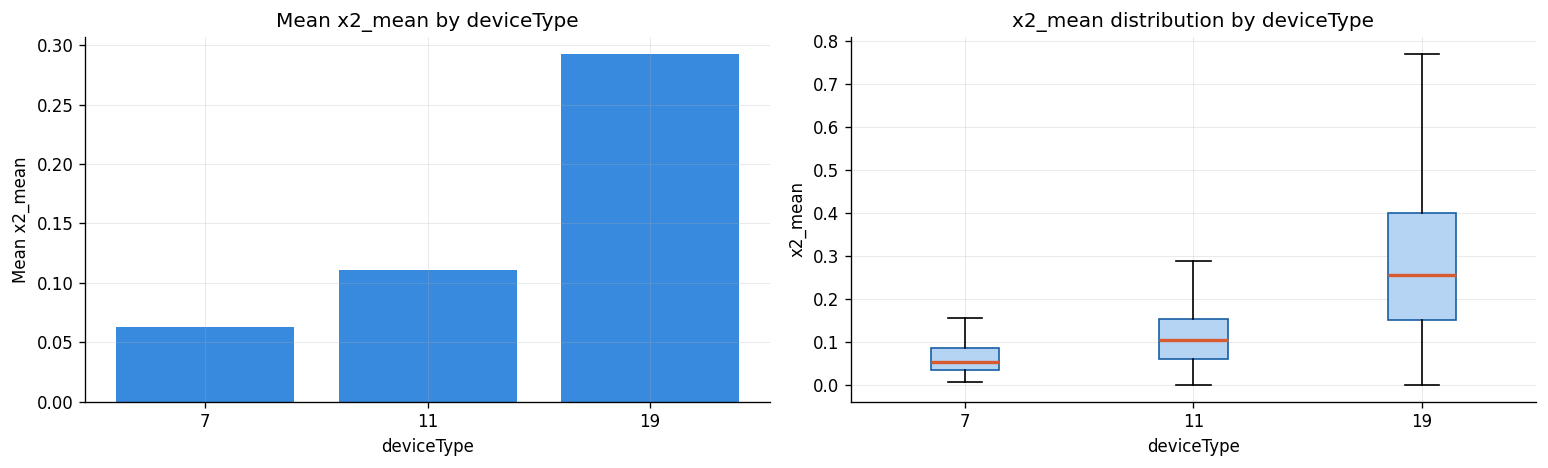

            count   mean    std    min    max
deviceType                                   
7             411  0.063  0.037  0.007  0.216
11           2535  0.111  0.061  0.000  0.338
19           1196  0.292  0.185  0.000  0.878


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

type_means = train_df.groupby("deviceType")["x2_mean"].mean().sort_values()
axes[0].bar(type_means.index.astype(str), type_means.values, color=BLUE)
axes[0].set_title("Mean x2_mean by deviceType")
axes[0].set_xlabel("deviceType")
axes[0].set_ylabel("Mean x2_mean")

# Boxplot per type
types = sorted(train_df["deviceType"].unique())
data  = [train_df[train_df["deviceType"]==t]["x2_mean"].dropna().values for t in types]
bp = axes[1].boxplot(data, labels=[str(t) for t in types], showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
                medianprops=dict(color=CORAL, linewidth=2))
axes[1].set_title("x2_mean distribution by deviceType")
axes[1].set_xlabel("deviceType")
axes[1].set_ylabel("x2_mean")

plt.tight_layout()
plt.show()

print(train_df.groupby("deviceType")["x2_mean"]
      .agg(["count","mean","std","min","max"]).round(3).to_string())

## 8. Geographic distribution

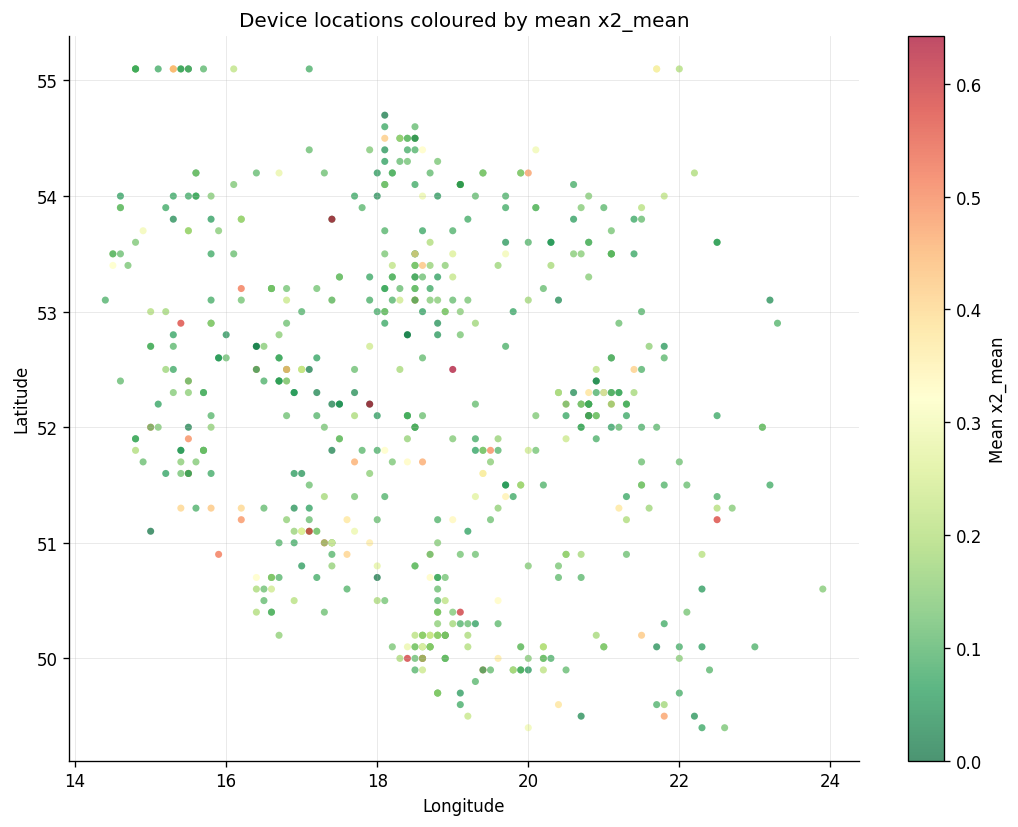

Lat/lon range:
  lat: 49.40 → 55.10
  lon: 14.40 → 23.90


In [9]:
dev_geo = (train_df.groupby("deviceId")
           .agg(mean_x2=("x2_mean","mean"),
                lat=("latitude","first"),
                lon=("longitude","first"))
           .reset_index())

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(dev_geo["lon"], dev_geo["lat"],
                c=dev_geo["mean_x2"], cmap="RdYlGn_r",
                s=18, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label="Mean x2_mean")
ax.set_title("Device locations coloured by mean x2_mean")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print("Lat/lon range:")
print(f"  lat: {dev_geo['lat'].min():.2f} → {dev_geo['lat'].max():.2f}")
print(f"  lon: {dev_geo['lon'].min():.2f} → {dev_geo['lon'].max():.2f}")

## 9. Data completeness — x2_count per device-month

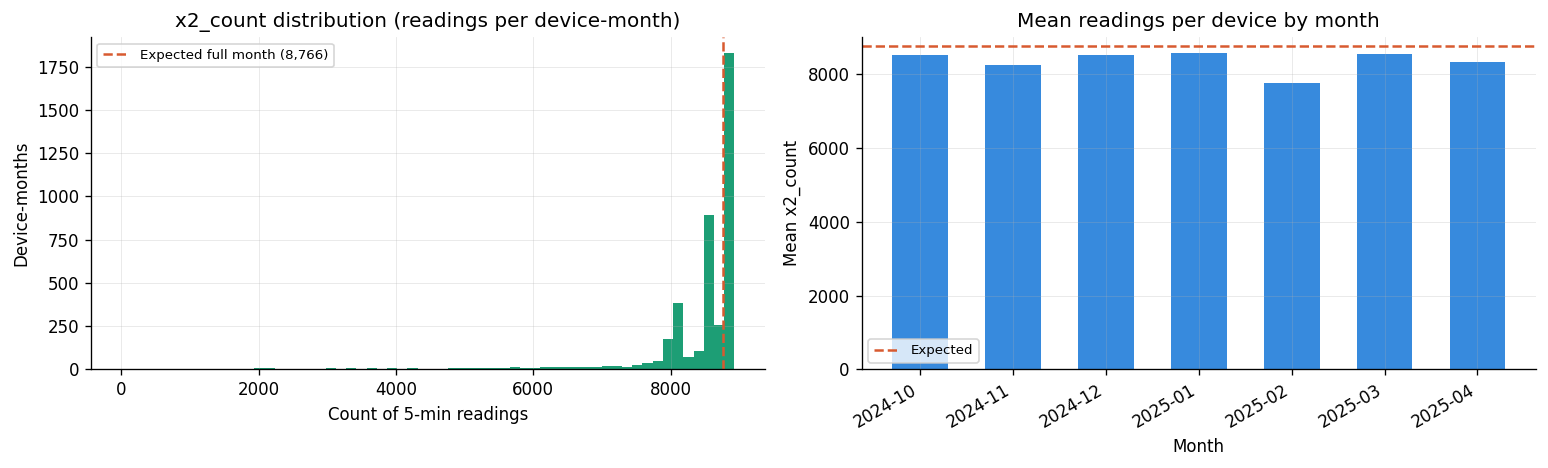

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of reading counts
axes[0].hist(train_df["x2_count"], bins=60, color=TEAL, edgecolor="none")
axes[0].set_title("x2_count distribution (readings per device-month)")
axes[0].set_xlabel("Count of 5-min readings")
axes[0].set_ylabel("Device-months")
expected = 30.44 * 24 * 12   # ~8,765 per month at 5-min
axes[0].axvline(expected, color=CORAL, linewidth=1.5, linestyle="--",
                label=f"Expected full month ({int(expected):,})")
axes[0].legend(fontsize=8)

# Mean count per month (data completeness over time)
count_by_month = (train_df.groupby(["year","month"])["x2_count"]
                  .mean().reset_index().sort_values(["year","month"]))
count_by_month["label"] = (count_by_month["year"].astype(str)+"-"
                           +count_by_month["month"].astype(str).str.zfill(2))
axes[1].bar(count_by_month["label"], count_by_month["x2_count"],
            color=BLUE, width=0.6)
axes[1].axhline(expected, color=CORAL, linewidth=1.5, linestyle="--",
                label="Expected")
axes[1].set_title("Mean readings per device by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean x2_count")
axes[1].legend(fontsize=8)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 10. Key takeaways
Fill these in after running the notebook.

In [11]:
summary = {
    "n_devices"          : df["deviceId"].nunique(),
    "n_train_months"     : train_df[["year","month"]].drop_duplicates().shape[0],
    "n_forecast_months"  : fore_df[["year","month"]].drop_duplicates().shape[0],
    "x2_mean_mean"       : train_df["x2_mean"].mean().round(4),
    "x2_mean_std"        : train_df["x2_mean"].std().round(4),
    "x2_zero_pct"        : (train_df["x2_mean"]==0).mean().round(4)*100,
    "top_corr_feature"   : train_df[TEMP_MEAN_COLS+["x1_mean"]].corrwith(
                               train_df["x2_mean"]).abs().idxmax(),
}
for k, v in summary.items():
    print(f"  {k:<25}: {v}")

  n_devices                : 600
  n_train_months           : 7
  n_forecast_months        : 6
  x2_mean_mean             : 0.15860000252723694
  x2_mean_std              : 0.14079999923706055
  x2_zero_pct              : 0.36
  top_corr_feature         : t8_mean
